In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs("Figures", exist_ok=True)

# Task 1: Dataset Exploration

In [3]:
columns = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']
df = pd.read_csv('data_banknote_authentication.txt', header=None, names=columns)

In [4]:
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [5]:
df.shape

(1372, 5)

In [6]:
df.isnull().sum()

Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [8]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


# Task 2: Exploratory Data Analysis

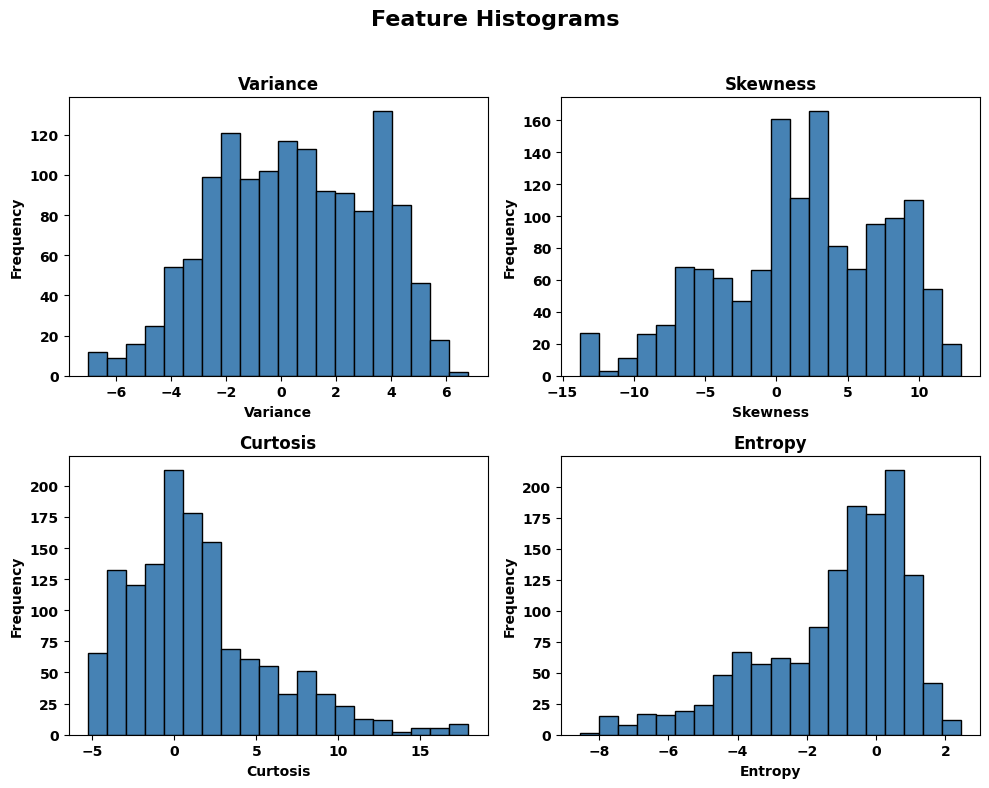

In [9]:
import matplotlib.pyplot as plt

features = ['Variance', 'Skewness', 'Curtosis', 'Entropy']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, feature in zip(axes, features):

    ax.hist(
        df[feature],
        bins=20,
        edgecolor='black',
        color='steelblue'
    )

    ax.set_title(feature, fontsize=12, fontweight='bold')
    ax.set_xlabel(feature, fontsize=10, fontweight='bold')
    ax.set_ylabel("Frequency", fontsize=10, fontweight='bold')

    for label in ax.get_xticklabels():
        label.set_fontweight('bold')

    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

plt.suptitle(
    "Feature Histograms",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig(
    "Figures/feature_histograms.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

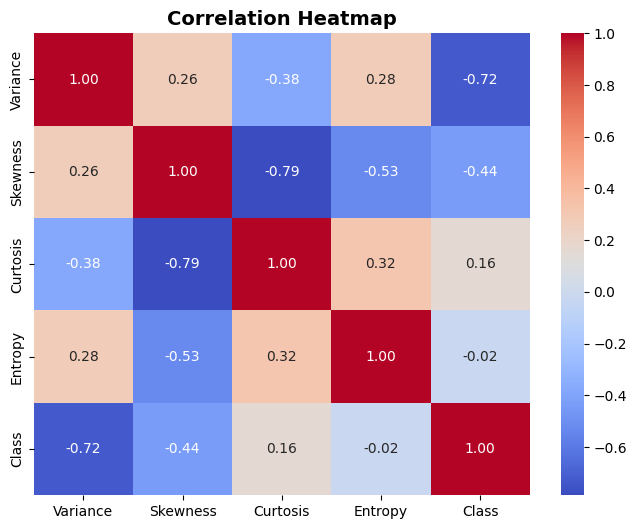

In [10]:
plt.figure(figsize=(8,6))

ax = sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.savefig(
    "Figures/correlation_heatmap.pdf",
    format="pdf",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

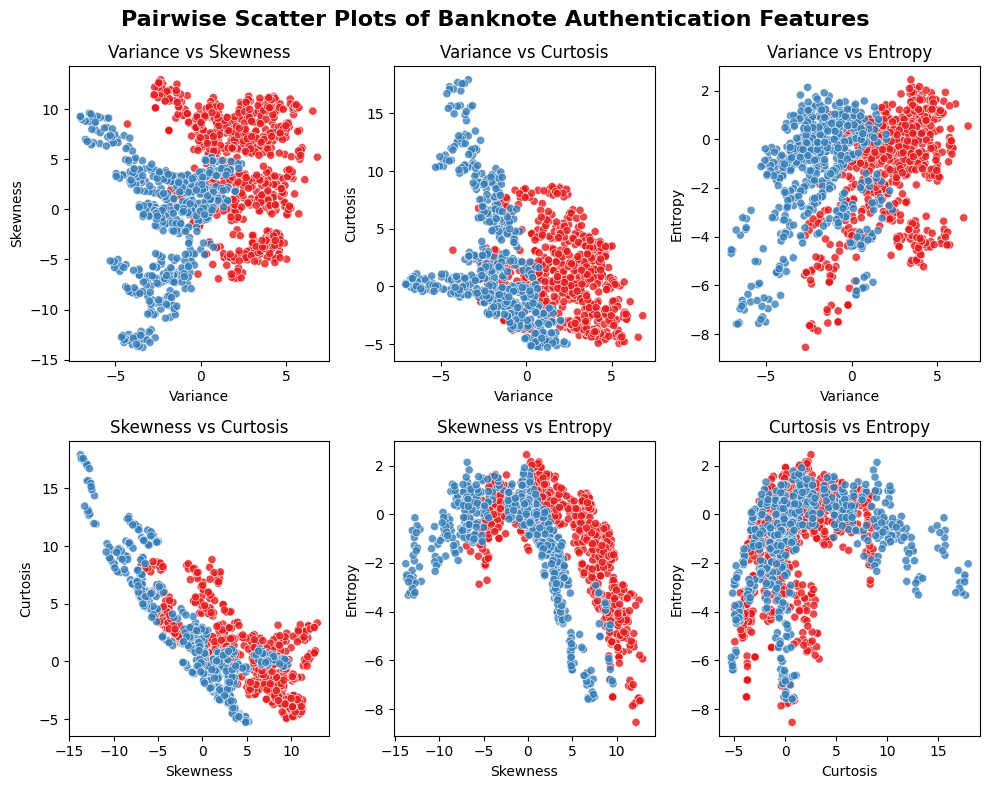

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

features = ['Variance', 'Skewness', 'Curtosis', 'Entropy']

fig, axes = plt.subplots(2, 3, figsize=(10, 8))

axes = axes.flatten()


for ax, (feature1,feature2) in zip(axes, combinations(features, 2)):
    sns.scatterplot(
    data=df,
    x=feature1,
    y=feature2,
    hue='Class',
    palette='Set1',
    s=35,
    alpha=0.8,
    ax=ax,
    legend=False
)

    ax.set_title(f"{feature1} vs {feature2}", fontsize=12)
    
plt.suptitle("Pairwise Scatter Plots of Banknote Authentication Features",
             fontsize=16,
             fontweight='bold')

plt.tight_layout()
plt.savefig(
    "Figures/scatter_plot_matrix.pdf",
    format="pdf",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

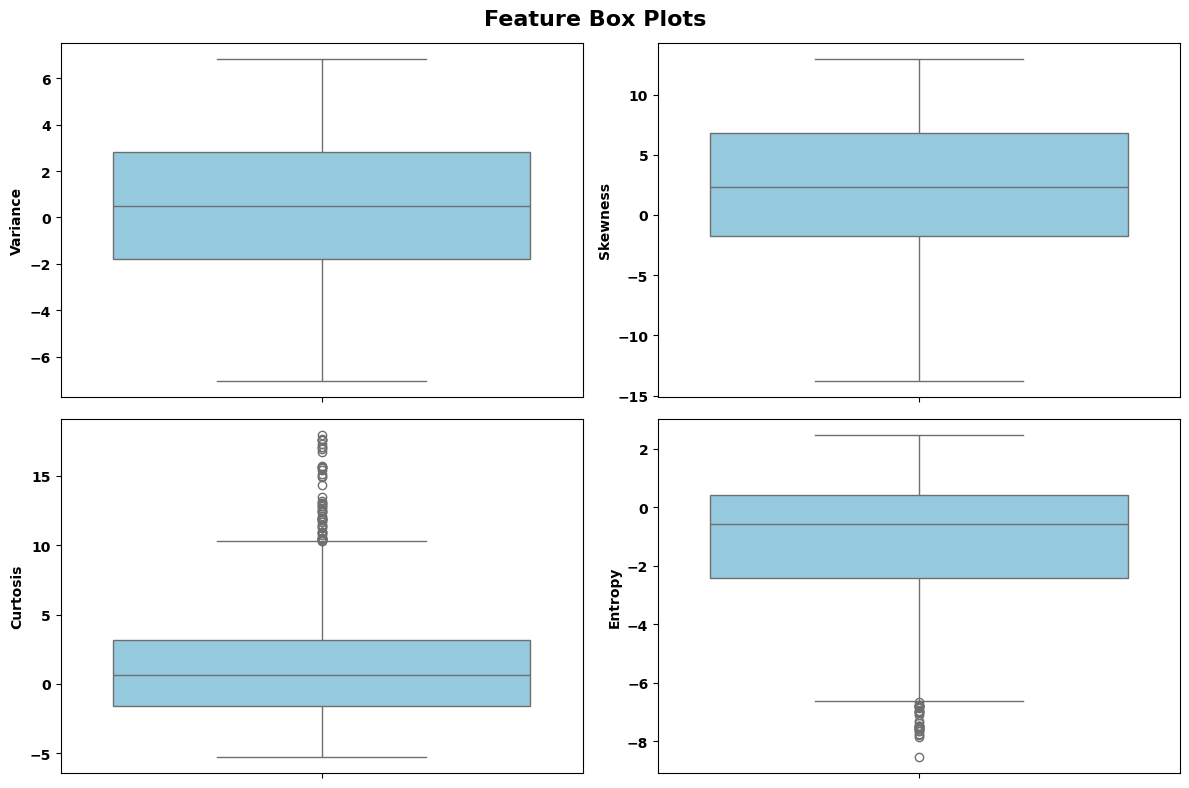

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['Variance', 'Skewness', 'Curtosis', 'Entropy']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(axes, features):

    sns.boxplot(
        y=df[feature],
        color='skyblue',
        ax=ax
    )

    ax.set_ylabel(feature, fontsize=10, fontweight='bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

plt.suptitle(
    "Feature Box Plots",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    "Figures/boxplots.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

# Task 3: Data Preprocessing

In [13]:
from sklearn.preprocessing import MinMaxScaler


X=df.drop('Class',axis=1)
y=df['Class']


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("First Five Rows of Normalized Features")
print(X_scaled.head())

First Five Rows of Normalized Features
   Variance  Skewness  Curtosis   Entropy
0  0.769004  0.839643  0.106783  0.736628
1  0.835659  0.820982  0.121804  0.644326
2  0.786629  0.416648  0.310608  0.786951
3  0.757105  0.871699  0.054921  0.450440
4  0.531578  0.348662  0.424662  0.687362


In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
X_scaled,
y,
test_size=0.20,
random_state=42,
stratify=y
)

print("\nTraining Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)

print("Training Label Shape   :", y_train.shape)
print("Testing Label Shape    :", y_test.shape)


Training Feature Shape : (1097, 4)
Testing Feature Shape  : (275, 4)
Training Label Shape   : (1097,)
Testing Label Shape    : (275,)


# Task 4: Perceptron Implementation

In [15]:
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

        self.errors = []
        self.weight_history = []
        self.bias_history = []
        self.accuracy_history = []     

    def initialize_parameters(self, n_features):

        self.weights = np.zeros(n_features)
        self.bias = 0

    def activation(self, x):

        if x >= 0:
            return 1
        else:
            return 0

    def predict(self, X):

        linear_output = np.dot(X, self.weights) + self.bias

        predictions = np.where(linear_output >= 0, 1, 0)

        return predictions

    def fit(self, X_train, y_train, X_test, y_test):

        self.initialize_parameters(X_train.shape[1])

        for epoch in range(self.epochs):

            errors = 0

            for i in range(len(X_train)):

                linear_output = np.dot(X_train[i], self.weights) + self.bias

                prediction = self.activation(linear_output)

                update = self.learning_rate * (y_train[i] - prediction)

                self.weights += update * X_train[i]

                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            
            y_pred = self.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            self.accuracy_history.append(accuracy)

            print(f"Epoch {epoch+1}")
            print(f"Misclassified Samples : {errors}")
            print(f"Accuracy : {accuracy:.4f}")
            print(f"Weights : {self.weights}")
            print(f"Bias : {self.bias}")
            print("\n")

            if errors == 0:
                print(f"\nTraining Converged at Epoch {epoch+1}")
                break

# Task 5: Model Training

In [16]:
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score,confusion_matrix
perceptron = Perceptron(
    learning_rate=0.01,
    epochs=100
)

perceptron.fit(
    X_train.values,
    y_train.values,
    X_test.values,
    y_test.values
)

Epoch 1
Misclassified Samples : 171
Accuracy : 0.9273
Weights : [-0.06792364 -0.04617278 -0.05904233  0.02213631]
Bias : 0.07


Epoch 2
Misclassified Samples : 101
Accuracy : 0.9709
Weights : [-0.08380509 -0.06774466 -0.08105979  0.00775587]
Bias : 0.09999999999999999


Epoch 3
Misclassified Samples : 43
Accuracy : 0.9927
Weights : [-0.08780541 -0.07827122 -0.08945257  0.00240271]
Bias : 0.10999999999999999


Epoch 4
Misclassified Samples : 43
Accuracy : 0.9709
Weights : [-0.09081985 -0.08978894 -0.09123274  0.00439111]
Bias : 0.11999999999999998


Epoch 5
Misclassified Samples : 57
Accuracy : 0.9709
Weights : [-0.09878964 -0.09827279 -0.09836367  0.0110804 ]
Bias : 0.12999999999999998


Epoch 6
Misclassified Samples : 43
Accuracy : 0.9455
Weights : [-0.0971687  -0.10179894 -0.10908865  0.0144443 ]
Bias : 0.13999999999999999


Epoch 7
Misclassified Samples : 30
Accuracy : 0.9927
Weights : [-0.11075321 -0.10405292 -0.11086234  0.00277833]
Bias : 0.13999999999999999


Epoch 8
Misclassifi

Epoch 70
Misclassified Samples : 18
Accuracy : 0.9891
Weights : [-0.18669051 -0.20028085 -0.20386324 -0.00820513]
Bias : 0.26000000000000006


Epoch 71
Misclassified Samples : 24
Accuracy : 0.9855
Weights : [-0.18296615 -0.20101328 -0.21087048 -0.00126208]
Bias : 0.26000000000000006


Epoch 72
Misclassified Samples : 20
Accuracy : 0.9927
Weights : [-0.18860354 -0.20255722 -0.20672534 -0.00567357]
Bias : 0.26000000000000006


Epoch 73
Misclassified Samples : 20
Accuracy : 0.9891
Weights : [-0.18500268 -0.20803225 -0.20757943 -0.00180287]
Bias : 0.26000000000000006


Epoch 74
Misclassified Samples : 18
Accuracy : 0.9891
Weights : [-0.18705023 -0.21227386 -0.20446631  0.00035829]
Bias : 0.26000000000000006


Epoch 75
Misclassified Samples : 18
Accuracy : 0.9927
Weights : [-0.18705262 -0.21143065 -0.20741807 -0.00115723]
Bias : 0.26000000000000006


Epoch 76
Misclassified Samples : 22
Accuracy : 0.9891
Weights : [-0.18522982 -0.20187432 -0.22184117 -0.00286565]
Bias : 0.26000000000000006



# Task 6: Model Evaluation

Accuracy : 0.9890909090909091
Recall: 0.9836065573770492
Precison: 0.9917355371900827
F1 score: 0.9876543209876543


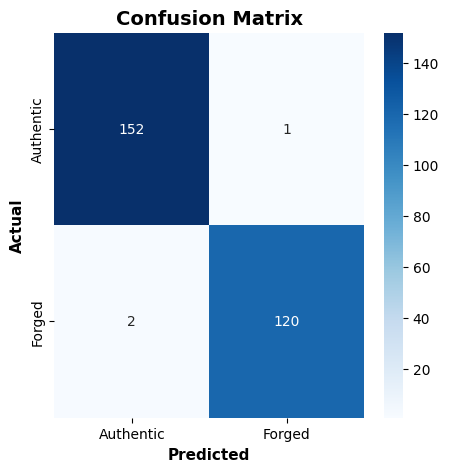

In [17]:
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score,confusion_matrix

y_pred = perceptron.predict(X_test.values)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

recall=recall_score(y_test,y_pred)
print("Recall:",recall)

precision=precision_score(y_test,y_pred)
print("Precison:",precision)

f1=f1_score(y_test,y_pred)
print("F1 score:",f1)


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Authentic','Forged'],
    yticklabels=['Authentic','Forged']
)

plt.xlabel("Predicted", fontsize=11, fontweight='bold')
plt.ylabel("Actual", fontsize=11, fontweight='bold')
plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.savefig(
    "Figures/confusionmatrix.pdf",
    format="pdf",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

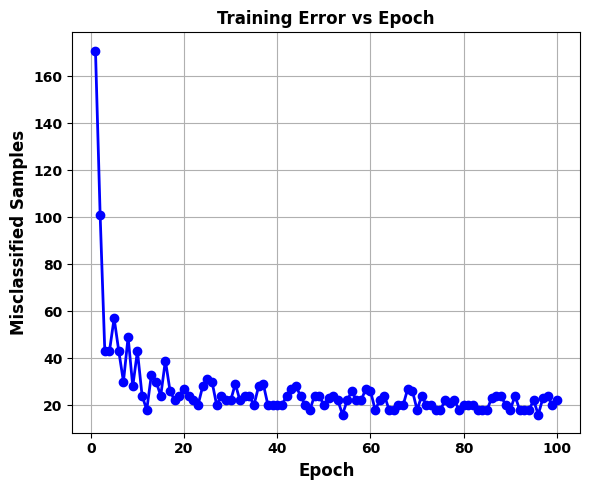

In [18]:
plt.figure(figsize=(6,5))

plt.plot(
    range(1, len(perceptron.errors)+1),
    perceptron.errors,
    marker='o',
    linewidth=2,
    color='blue'
)

plt.title("Training Error vs Epoch", fontsize=12, fontweight='bold')
plt.xlabel("Epoch", fontsize=12, fontweight='bold')
plt.ylabel("Misclassified Samples", fontsize=12, fontweight='bold')

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.grid(True)

plt.tight_layout()
plt.savefig(
    "Figures/training_error.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


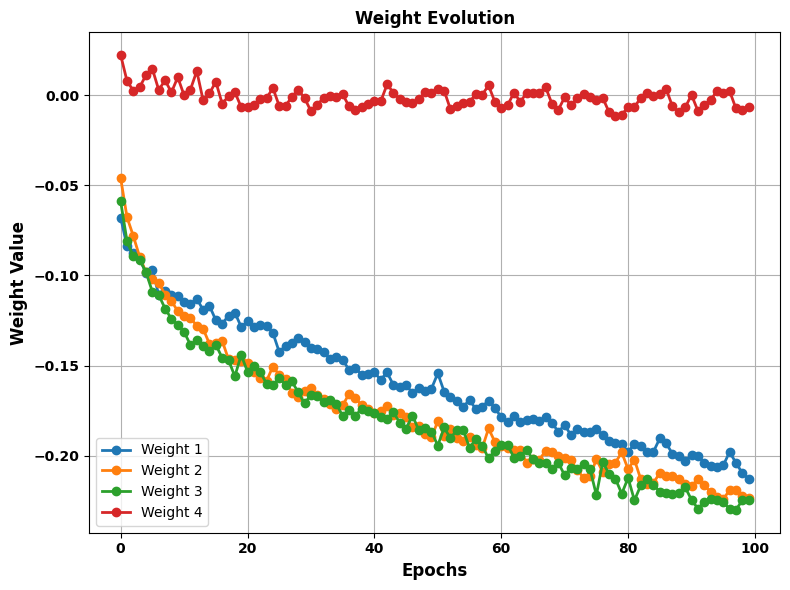

In [19]:
weights = np.array(perceptron.weight_history)

plt.figure(figsize=(8,6))
for i in range(weights.shape[1]):
    plt.plot(
        weights[:, i],
        linewidth=2,
        marker='o',
        label=f'Weight {i+1}'
    )

plt.title("Weight Evolution", fontsize=12, fontweight='bold')
plt.xlabel("Epochs", fontsize=12, fontweight='bold')
plt.ylabel("Weight Value", fontsize=12, fontweight='bold')

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(
    "Figures/weight_evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

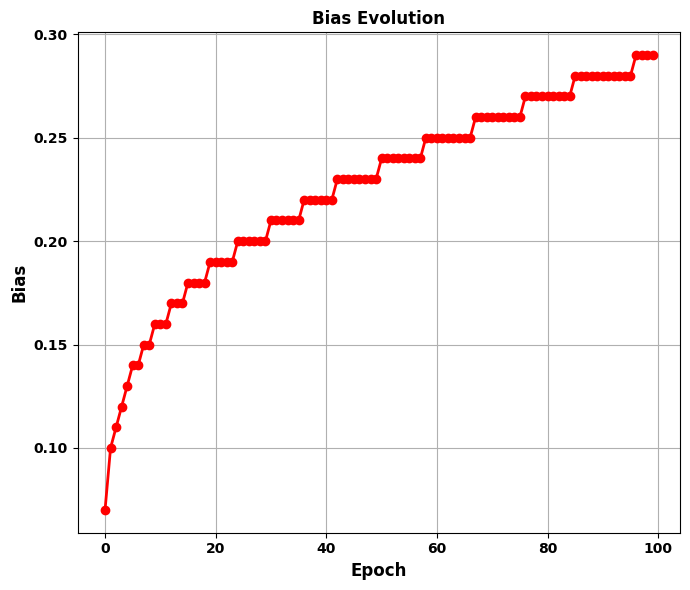

In [20]:
plt.figure(figsize=(7,6))
plt.plot(
    perceptron.bias_history,
    marker='o',
    linewidth=2,
    color='red'
)

plt.title("Bias Evolution", fontsize=12, fontweight='bold')
plt.xlabel("Epoch", fontsize=12, fontweight='bold')
plt.ylabel("Bias", fontsize=12, fontweight='bold')

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.grid(True)

plt.tight_layout()
plt.savefig(
    "Figures/bias_evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

Epoch 1
Misclassified Samples : 171
Accuracy : 0.9273
Weights : [-0.00679236 -0.00461728 -0.00590423  0.00221363]
Bias : 0.007


Epoch 2
Misclassified Samples : 101
Accuracy : 0.9709
Weights : [-0.00838051 -0.00677447 -0.00810598  0.00077559]
Bias : 0.010000000000000002


Epoch 3
Misclassified Samples : 43
Accuracy : 0.9927
Weights : [-0.00878054 -0.00782712 -0.00894526  0.00024027]
Bias : 0.011000000000000003


Epoch 4
Misclassified Samples : 43
Accuracy : 0.9709
Weights : [-0.00908198 -0.00897889 -0.00912327  0.00043911]
Bias : 0.012000000000000004


Epoch 5
Misclassified Samples : 57
Accuracy : 0.9709
Weights : [-0.00987896 -0.00982728 -0.00983637  0.00110804]
Bias : 0.013000000000000005


Epoch 6
Misclassified Samples : 43
Accuracy : 0.9455
Weights : [-0.00971687 -0.01017989 -0.01090887  0.00144443]
Bias : 0.014000000000000005


Epoch 7
Misclassified Samples : 30
Accuracy : 0.9927
Weights : [-0.01107532 -0.01040529 -0.01108623  0.00027783]
Bias : 0.014000000000000005


Epoch 8
Misc

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


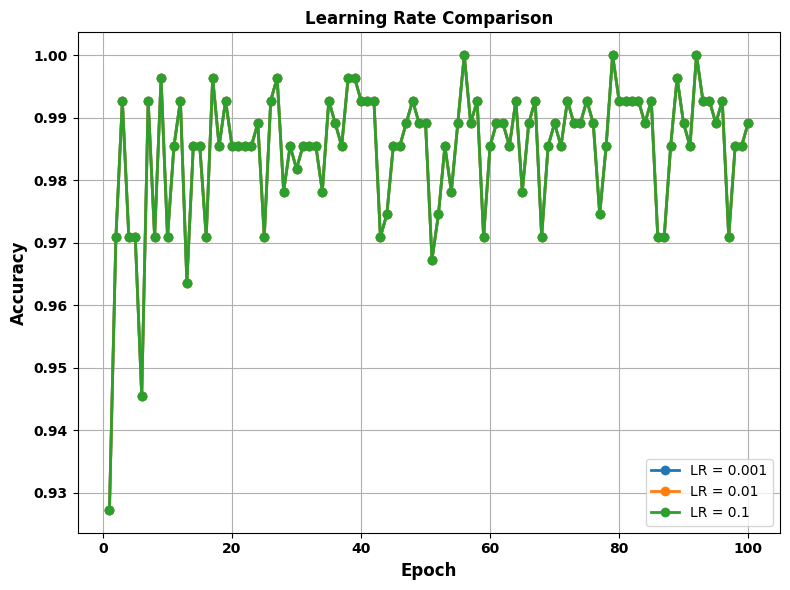

Epoch 84
Misclassified Samples : 18
Accuracy : 0.9891
Weights : [-1.97755767 -2.15795924 -2.13124711  0.00851155]
Bias : 2.700000000000001


Epoch 85
Misclassified Samples : 18
Accuracy : 0.9927
Weights : [-1.97758161 -2.14952715 -2.16076467 -0.00664359]
Bias : 2.700000000000001


Epoch 86
Misclassified Samples : 23
Accuracy : 0.9709
Weights : [-1.90347117 -2.09632573 -2.19949929  0.00523225]
Bias : 2.800000000000001


Epoch 87
Misclassified Samples : 24
Accuracy : 0.9709
Weights : [-1.93088177 -2.1107119  -2.20913002  0.03369884]
Bias : 2.800000000000001


Epoch 88
Misclassified Samples : 24
Accuracy : 0.9855
Weights : [-1.98982349 -2.1121521  -2.21427254 -0.06356104]
Bias : 2.800000000000001


Epoch 89
Misclassified Samples : 20
Accuracy : 0.9964
Weights : [-2.00162584 -2.1316642  -2.20676467 -0.09442474]
Bias : 2.800000000000001


Epoch 90
Misclassified Samples : 18
Accuracy : 0.9891
Weights : [-2.03076155 -2.15925201 -2.17461855 -0.06901558]
Bias : 2.800000000000001


Epoch 91
Misc

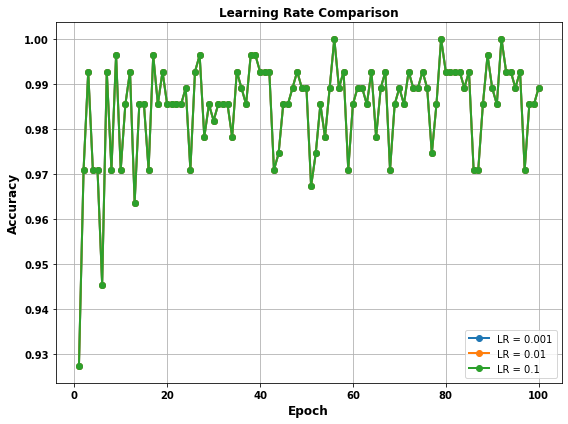

In [21]:
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(8,6))

for lr in learning_rates:

    model = Perceptron(
        learning_rate=lr,
        epochs=100
    )

    model.fit(
        X_train.values,
        y_train.values,
        X_test.values,
        y_test.values
    )

    plt.plot(
        range(1, len(model.accuracy_history)+1),
        model.accuracy_history,
        marker='o',
        linewidth=2,
        label=f'LR = {lr}'
    )

plt.title("Learning Rate Comparison", fontsize=12, fontweight='bold')
plt.xlabel("Epoch", fontsize=12, fontweight='bold')
plt.ylabel("Accuracy", fontsize=12, fontweight='bold')

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig(
    "Figures/learning_rate_comparison.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

Epoch 1
Misclassified Samples : 3
Accuracy : 0.4446
Weights : [0.00174049 0.0030995 ]
Bias : 0.01


Epoch 2
Misclassified Samples : 2
Accuracy : 0.4446
Weights : [-0.0018787   0.00109873]
Bias : 0.01


Epoch 3
Misclassified Samples : 2
Accuracy : 0.4446
Weights : [-0.0054979  -0.00090205]
Bias : 0.01


Epoch 4
Misclassified Samples : 2
Accuracy : 0.4854
Weights : [-0.00911709 -0.00290282]
Bias : 0.01


Epoch 5
Misclassified Samples : 3
Accuracy : 0.4446
Weights : [-0.00731634  0.00150756]
Bias : 0.02


Epoch 6
Misclassified Samples : 4
Accuracy : 0.4446
Weights : [-0.0094887  -0.00084939]
Bias : 0.02


Epoch 7
Misclassified Samples : 2
Accuracy : 0.4446
Weights : [-0.01310789 -0.00285016]
Bias : 0.02


Epoch 8
Misclassified Samples : 2
Accuracy : 0.4461
Weights : [-0.01672708 -0.00485093]
Bias : 0.02


Epoch 9
Misclassified Samples : 2
Accuracy : 0.6042
Weights : [-0.02034628 -0.0068517 ]
Bias : 0.02


Epoch 10
Misclassified Samples : 2
Accuracy : 0.7041
Weights : [-0.02414172 -0.00462

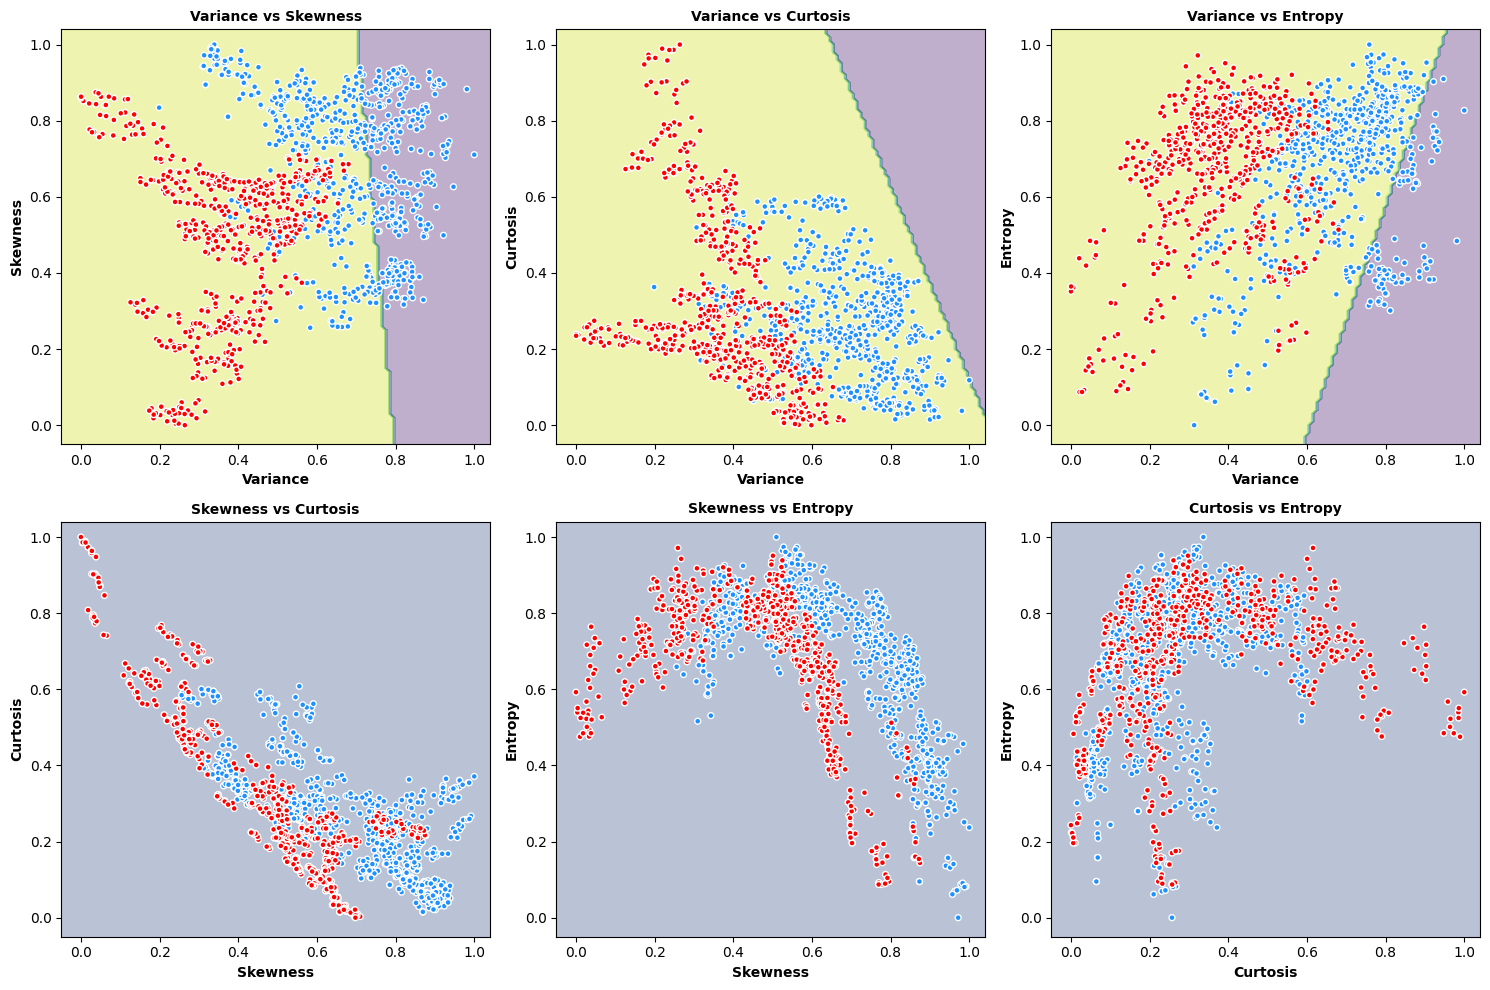

In [22]:
from itertools import combinations
from matplotlib.colors import ListedColormap

features = ['Variance', 'Skewness', 'Curtosis', 'Entropy']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for ax, (f1, f2) in zip(axes, combinations(features, 2)):

    # Select two features
    X = X_scaled[[f1, f2]].values

    # Train perceptron
    model = Perceptron(learning_rate=0.01, epochs=100)
    model.fit(X, y.values, X, y.values)

    # Create mesh grid
    x_min, x_max = X[:,0].min()-0.05, X[:,0].max()+0.05
    y_min, y_max = X[:,1].min()-0.05, X[:,1].max()+0.05

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01)
    )

    # Predict on grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Decision boundary
    ax.contourf(xx, yy, Z, alpha=0.35, cmap='viridis')

    # Data points
    ax.scatter(
        X[:,0],
        X[:,1],
        c=y,
        cmap=ListedColormap(['dodgerblue', 'red']),
        edgecolors='white',
        s=18
    )

    ax.set_title(f"{f1} vs {f2}", fontsize=10, fontweight='bold')
    ax.set_xlabel(f1, fontweight='bold')
    ax.set_ylabel(f2, fontweight='bold')

plt.tight_layout()
plt.savefig(
    "Figures/decision_boundary.pdf",
    format="pdf",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

# Additional Tasks

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


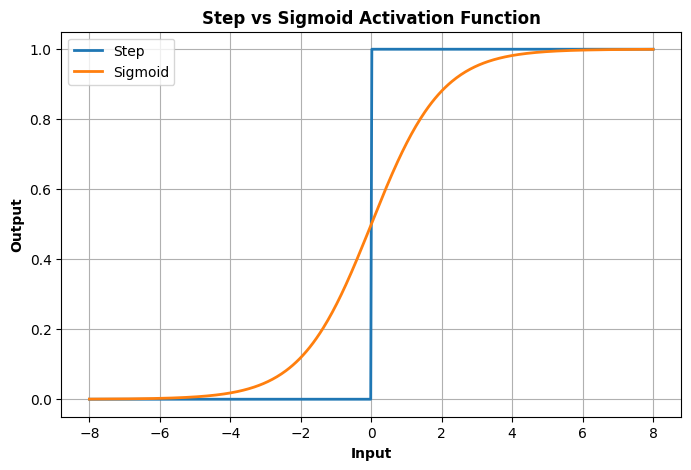

In [23]:
x = np.linspace(-8,8,500)

step = np.where(x>=0,1,0)
sigmoid = 1/(1+np.exp(-x))

plt.figure(figsize=(8,5))

plt.plot(x,step,label="Step",linewidth=2)
plt.plot(x,sigmoid,label="Sigmoid",linewidth=2)

plt.xlabel("Input",fontweight="bold")
plt.ylabel("Output",fontweight="bold")
plt.title("Step vs Sigmoid Activation Function",fontweight="bold")

plt.grid(True)
plt.legend()

plt.savefig(
    "Figures/step_vs_sigmoid.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


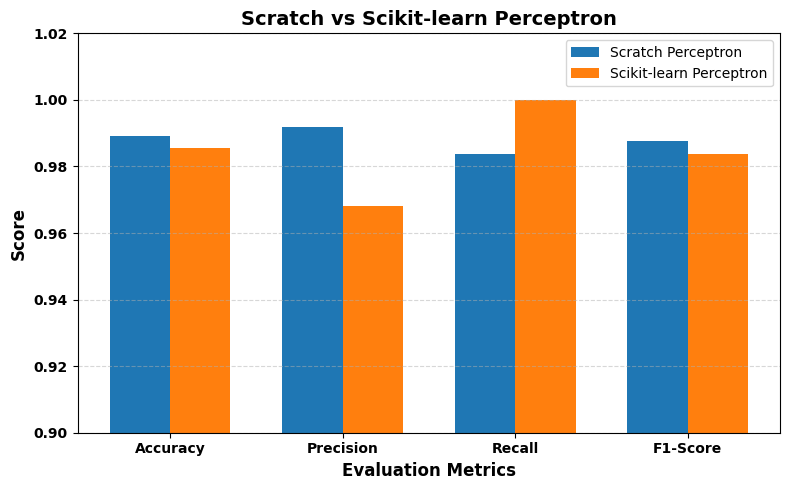

In [24]:
from sklearn.linear_model import Perceptron as SKPerceptron

scratch_predictions = perceptron.predict(X_test.values)

scratch_accuracy = accuracy_score(y_test, scratch_predictions)
scratch_precision = precision_score(y_test, scratch_predictions)
scratch_recall = recall_score(y_test, scratch_predictions)
scratch_f1 = f1_score(y_test, scratch_predictions)

# -------------------------------
# Scikit-learn Perceptron
# -------------------------------
sk_model = SKPerceptron(
    eta0=0.01,
    max_iter=100,
    tol=None,
    random_state=42
)

sk_model.fit(X_train, y_train)

sk_predictions = sk_model.predict(X_test)

sk_accuracy = accuracy_score(y_test, sk_predictions)
sk_precision = precision_score(y_test, sk_predictions)
sk_recall = recall_score(y_test, sk_predictions)
sk_f1 = f1_score(y_test, sk_predictions)

# -------------------------------
# Data for plotting
# -------------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

scratch_scores = [
    scratch_accuracy,
    scratch_precision,
    scratch_recall,
    scratch_f1
]

sk_scores = [
    sk_accuracy,
    sk_precision,
    sk_recall,
    sk_f1
]

x = np.arange(len(metrics))
width = 0.35

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    scratch_scores,
    width,
    label="Scratch Perceptron"
)

plt.bar(
    x + width/2,
    sk_scores,
    width,
    label="Scikit-learn Perceptron"
)

plt.xticks(x, metrics, fontweight="bold")
plt.yticks(fontweight="bold")

plt.xlabel("Evaluation Metrics", fontsize=12, fontweight="bold")
plt.ylabel("Score", fontsize=12, fontweight="bold")

plt.ylim(0.90, 1.02)

plt.title(
    "Scratch vs Scikit-learn Perceptron",
    fontsize=14,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend()

plt.tight_layout()

plt.savefig(
    "Figures/sklearn_comparison.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


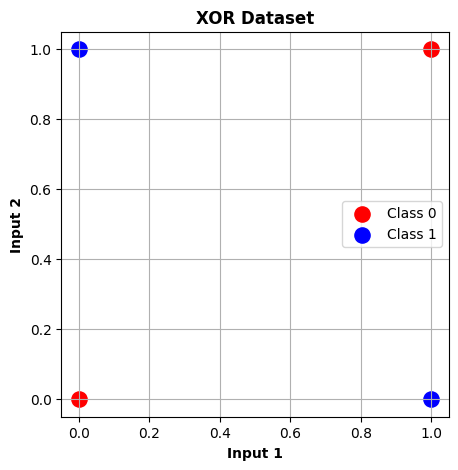

In [25]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,0])

plt.figure(figsize=(5,5))

plt.scatter(
    X[y==0][:,0],
    X[y==0][:,1],
    color="red",
    s=120,
    label="Class 0"
)

plt.scatter(
    X[y==1][:,0],
    X[y==1][:,1],
    color="blue",
    s=120,
    label="Class 1"
)

plt.xlabel("Input 1",fontweight="bold")
plt.ylabel("Input 2",fontweight="bold")

plt.title("XOR Dataset",fontweight="bold")

plt.legend()
plt.grid(True)

plt.savefig(
    "Figures/xor_problem.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Epoch 1
Misclassified Samples : 31
Accuracy : 0.8404
Weights : [-0.0977521  -0.035488   -0.04067674 -0.08737502]
Bias : 0.21000000000000005


Epoch 2
Misclassified Samples : 19
Accuracy : 0.9614
Weights : [-0.2062165  -0.10696    -0.14164474 -0.10086534]
Bias : 0.26000000000000006


Epoch 3
Misclassified Samples : 21
Accuracy : 0.9585
Weights : [-0.2214905  -0.179737   -0.14699074 -0.16727861]
Bias : 0.35000000000000014


Epoch 4
Misclassified Samples : 14
Accuracy : 0.9883
Weights : [-0.2790847  -0.21059    -0.23858274 -0.10420641]
Bias : 0.37000000000000016


Epoch 5
Misclassified Samples : 14
Accuracy : 0.9497
Weights : [-0.3369663  -0.2323791  -0.14416854 -0.12189718]
Bias : 0.4300000000000002


Epoch 6
Misclassified Samples : 18
Accuracy : 0.9796
Weights : [-0.3040204  -0.2312401  -0.25234654 -0.10554795]
Bias : 0.47000000000000025


Epoch 7
Misclassified Samples : 11
Accuracy : 0.9905
Weights : [-0.3896698  -0.2331641  -0.28035344 -0.07976692]
Bias : 0.46000000000000024


Epoch 8

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Epoch 96
Misclassified Samples : 4
Accuracy : 0.8324
Weights : [-0.08214635 -0.04647134 -0.07552054  0.03378908]
Bias : 0.08


Epoch 97
Misclassified Samples : 4
Accuracy : 0.9227
Weights : [-0.08482628 -0.05130447 -0.07061727  0.03338117]
Bias : 0.08


Epoch 98
Misclassified Samples : 2
Accuracy : 0.8936
Weights : [-0.08478238 -0.04969083 -0.07260051  0.03459928]
Bias : 0.08


Epoch 99
Misclassified Samples : 2
Accuracy : 0.8586
Weights : [-0.08473848 -0.04807719 -0.07458375  0.03581739]
Bias : 0.08


Epoch 100
Misclassified Samples : 4
Accuracy : 0.8520
Weights : [-0.08261134 -0.04841092 -0.07851926  0.03605492]
Bias : 0.08




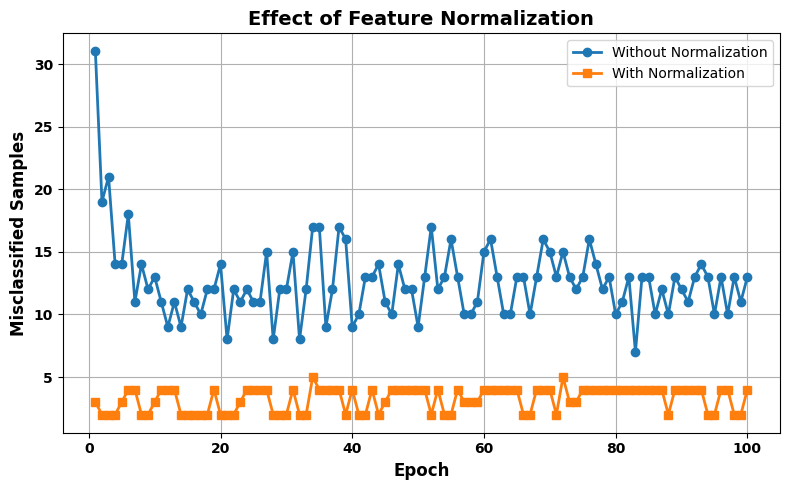

In [26]:
X_original = df[['Variance', 'Skewness', 'Curtosis', 'Entropy']].values
y_original = df['Class'].values

# Normalized Data
X_normalized = X_scaled.values

# Train without Normalization
model_without_scaling = Perceptron(
    learning_rate=0.01,
    epochs=100
)

model_without_scaling.fit(
    X_original,
    y_original,
    X_original,
    y_original
)

# Train with Normalization

model_with_scaling = Perceptron(
    learning_rate=0.01,
    epochs=100
)

model_with_scaling.fit(
    X_normalized,
    y_original,
    X_normalized,
    y_original
)

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(model_without_scaling.errors)+1),
    model_without_scaling.errors,
    marker='o',
    linewidth=2,
    label='Without Normalization'
)

plt.plot(
    range(1, len(model_with_scaling.errors)+1),
    model_with_scaling.errors,
    marker='s',
    linewidth=2,
    label='With Normalization'
)

plt.title(
    "Effect of Feature Normalization",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    "Epoch",
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    "Misclassified Samples",
    fontsize=12,
    fontweight='bold'
)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    "Figures/normalization_effect.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Epoch 1
Input [0 0]
Weights [0. 0.]
Bias -0.1
Input [1 1]
Weights [0.1 0.1]
Bias 0.0
Epoch 2
Input [0 0]
Weights [0.1 0.1]
Bias -0.1
Input [0 1]
Weights [0.1 0. ]
Bias -0.2
Input [1 1]
Weights [0.2 0.1]
Bias -0.1
Epoch 3
Input [0 1]
Weights [0.2 0. ]
Bias -0.2
Input [1 0]
Weights [0.1 0. ]
Bias -0.30000000000000004
Input [1 1]
Weights [0.2 0.1]
Bias -0.20000000000000004
Epoch 4
Training converged


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


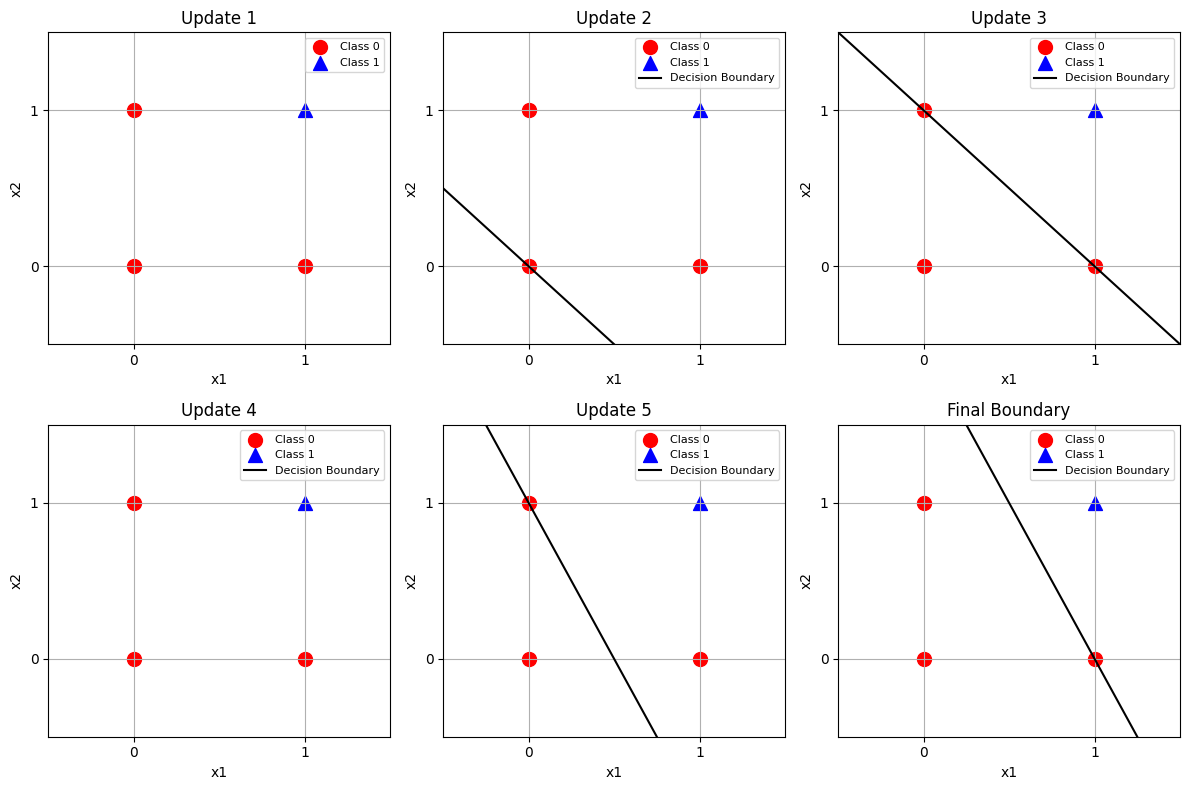

--------------------
Final Weights: [0.2 0.1]
Final Bias: -0.20000000000000004


In [27]:
data=np.array([[0,0],[0,1],[1,0],[1,1]])
target=np.array([0,0,0,1])

w=np.zeros(2)
b=0
lr=0.1
epochs=10

os.makedirs("Figures",exist_ok=True)

def step(z):
    if z>=0:
        return 1
    return 0

fig,axes=plt.subplots(2,3,figsize=(12,8))
axes=axes.flatten()
plot_no=0

def plot_boundary(ax,w,b,data,target,title):
    for i in range(len(data)):
        if target[i]==0:
            ax.scatter(data[i][0],data[i][1],c='red',marker='o',s=100,label='Class 0' if i==0 else "")
        else:
            ax.scatter(data[i][0],data[i][1],c='blue',marker='^',s=100,label='Class 1' if i==3 else "")

    if abs(w[1])>1e-8:
        x=np.linspace(-0.5,1.5,100)
        y=-(w[0]*x+b)/w[1]
        ax.plot(x,y,'k',label='Decision Boundary')
    elif abs(w[0])>1e-8:
        ax.axvline(-b/w[0],color='black',label='Decision Boundary')

    ax.set_xlim(-0.5,1.5)
    ax.set_ylim(-0.5,1.5)
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    ax.grid(True)
    ax.legend(fontsize=8)

for epoch in range(epochs):
    print("Epoch",epoch+1)
    updated=False

    for x,actual in zip(data,target):

        z=np.dot(w,x)+b
        pred=step(z)
        error=actual-pred

        w=w+lr*x*error
        b=b+lr*error

        if error!=0:

            print("Input",x)
            print("Weights",w)
            print("Bias",b)

            if plot_no<5:
                plot_boundary(axes[plot_no],w,b,data,target,f"Update {plot_no+1}")
                plot_no+=1

            updated=True

    if not updated:
        print("Training converged")
        break

plot_boundary(axes[5],w,b,data,target,"Final Boundary")

plt.tight_layout()
plt.savefig("Figures/AND_Decision_Boundary.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")
plt.show()

print("-"*20)
print("Final Weights:",w)
print("Final Bias:",b)

Epoch 1
Input [0 0]
Weights [0. 0.]
Bias -0.1
Input [0 1]
Weights [0.  0.1]
Bias 0.0
Epoch 2
Input [0 0]
Weights [0.  0.1]
Bias -0.1
Input [1 0]
Weights [0.1 0.1]
Bias 0.0
Epoch 3
Input [0 0]
Weights [0.1 0.1]
Bias -0.1
Epoch 4
Training converged


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


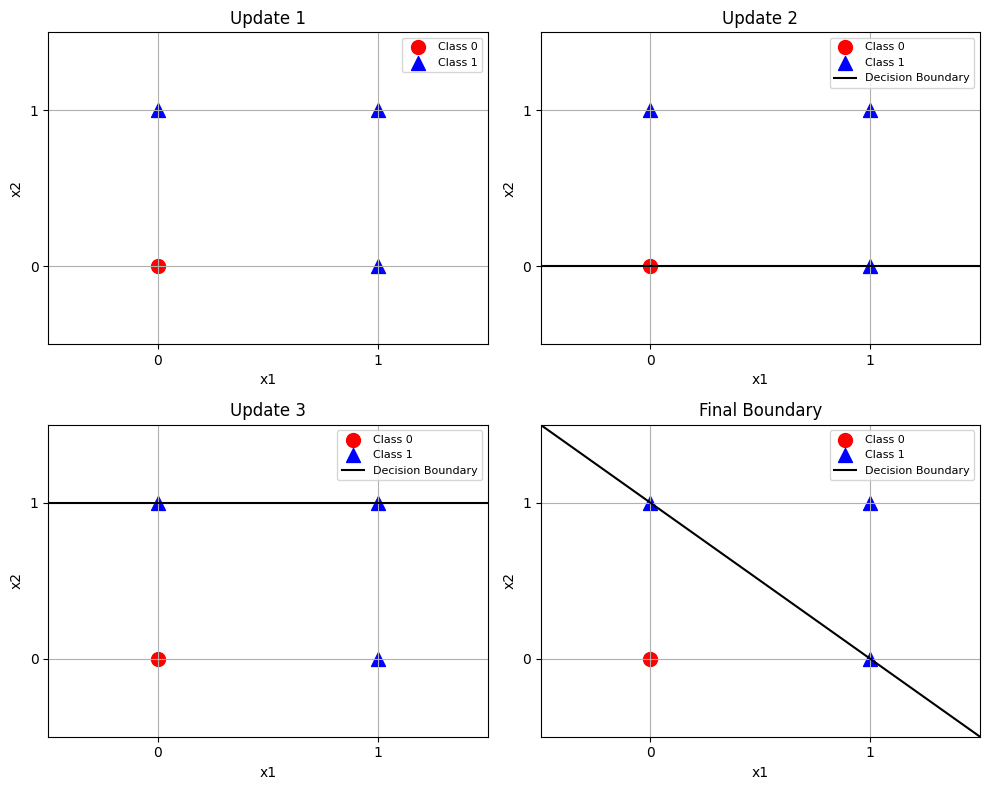

--------------------
Final Weights: [0.1 0.1]
Final Bias: -0.1


In [28]:
data=np.array([[0,0],[0,1],[1,0],[1,1]])
target=np.array([0,1,1,1])

w=np.zeros(2)
b=0
lr=0.1
epochs=10

os.makedirs("Figures",exist_ok=True)

def step(z):
    if z>=0:
        return 1
    return 0

fig,axes=plt.subplots(2,2,figsize=(10,8))
axes=axes.flatten()
plot_no=0

def plot_boundary(ax,w,b,data,target,title):
    for i in range(len(data)):
        if target[i]==0:
            ax.scatter(data[i][0],data[i][1],c='red',marker='o',s=100,label='Class 0' if i==0 else "")
        else:
            ax.scatter(data[i][0],data[i][1],c='blue',marker='^',s=100,label='Class 1' if i==1 else "")

    if abs(w[1])>1e-8:
        x=np.linspace(-0.5,1.5,100)
        y=-(w[0]*x+b)/w[1]
        ax.plot(x,y,'k',label='Decision Boundary')
    elif abs(w[0])>1e-8:
        ax.axvline(-b/w[0],color='black',label='Decision Boundary')

    ax.set_xlim(-0.5,1.5)
    ax.set_ylim(-0.5,1.5)
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    ax.grid(True)
    ax.legend(fontsize=8)

for epoch in range(epochs):
    print("Epoch",epoch+1)
    updated=False

    for x,actual in zip(data,target):

        z=np.dot(w,x)+b
        pred=step(z)
        error=actual-pred

        w=w+lr*x*error
        b=b+lr*error

        if error!=0:

            print("Input",x)
            print("Weights",w)
            print("Bias",b)

            if plot_no<3:
                plot_boundary(axes[plot_no],w,b,data,target,f"Update {plot_no+1}")
                plot_no+=1

            updated=True

    if not updated:
        print("Training converged")
        break

plot_boundary(axes[3],w,b,data,target,"Final Boundary")

plt.tight_layout()
plt.savefig("Figures/OR_Decision_Boundary.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")
plt.show()

print("-"*20)
print("Final Weights:",w)
print("Final Bias:",b)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Epoch 1
Input [1]
Weights [-0.1]
Bias -0.1
Epoch 2
Input [0]
Weights [-0.1]
Bias 0.0
Epoch 3
Training converged


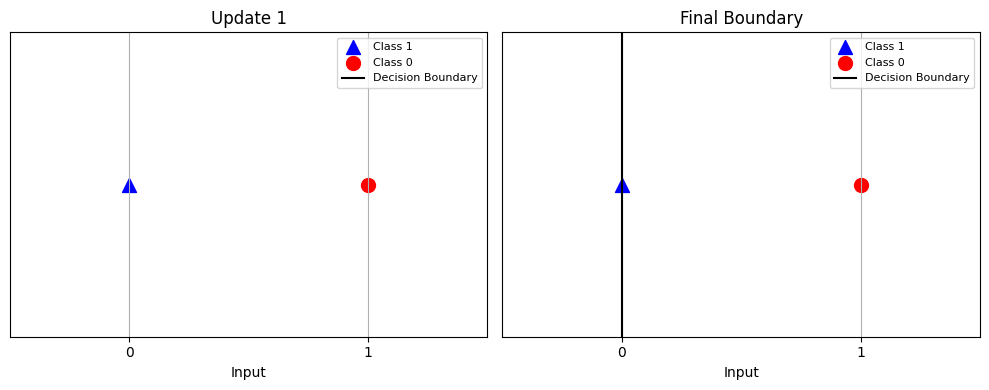

--------------------
Final Weights: [-0.1]
Final Bias: 0.0


In [29]:
data=np.array([[0],[1]])
target=np.array([1,0])

w=np.zeros(1)
b=0
lr=0.1
epochs=10

os.makedirs("Figures",exist_ok=True)

def step(z):
    if z>=0:
        return 1
    return 0

fig,axes=plt.subplots(1,2,figsize=(10,4))
plot_no=0

def plot_boundary(ax,w,b,data,target,title):
    for i in range(len(data)):
        if target[i]==0:
            ax.scatter(data[i][0],0,c='red',marker='o',s=100,label='Class 0' if i==1 else "")
        else:
            ax.scatter(data[i][0],0,c='blue',marker='^',s=100,label='Class 1' if i==0 else "")

    if abs(w[0])>1e-8:
        boundary=-b/w[0]
        ax.axvline(boundary,color='black',label='Decision Boundary')

    ax.set_xlim(-0.5,1.5)
    ax.set_ylim(-0.5,0.5)
    ax.set_xticks([0,1])
    ax.set_yticks([])
    ax.set_xlabel("Input")
    ax.set_title(title)
    ax.grid(True)
    ax.legend(fontsize=8)

for epoch in range(epochs):
    print("Epoch",epoch+1)
    updated=False

    for x,actual in zip(data,target):

        z=np.dot(w,x)+b
        pred=step(z)
        error=actual-pred

        w=w+lr*x*error
        b=b+lr*error

        if error!=0:

            print("Input",x)
            print("Weights",w)
            print("Bias",b)

            if plot_no<1:
                plot_boundary(axes[plot_no],w,b,data,target,f"Update {plot_no+1}")
                plot_no+=1

            updated=True

    if not updated:
        print("Training converged")
        break

plot_boundary(axes[1],w,b,data,target,"Final Boundary")

plt.tight_layout()
plt.savefig("Figures/NOT_Decision_Boundary.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")
plt.show()

print("-"*20)
print("Final Weights:",w)
print("Final Bias:",b)

Epoch 1
Update 1
Input [0 0]
Weights [0. 0.]
Bias -0.1
Update 2
Input [0 1]
Weights [0.  0.1]
Bias 0.0
Update 3
Input [1 1]
Weights [-0.1  0. ]
Bias -0.1
Epoch 2
Update 4
Input [0 1]
Weights [-0.1  0.1]
Bias 0.0
Update 5
Input [1 0]
Weights [0.  0.1]
Bias 0.1
Update 6
Input [1 1]
Weights [-0.1  0. ]
Bias 0.0
Epoch 3
Update 7
Input [0 0]
Weights [-0.1  0. ]
Bias -0.1
Update 8
Input [0 1]
Weights [-0.1  0.1]
Bias 0.0
Update 9
Input [1 0]
Weights [0.  0.1]
Bias 0.1
Update 10
Input [1 1]
Weights [-0.1  0. ]
Bias 0.0
Epoch 4
Update 11
Input [0 0]
Weights [-0.1  0. ]
Bias -0.1
Update 12
Input [0 1]
Weights [-0.1  0.1]
Bias 0.0
Update 13
Input [1 0]
Weights [0.  0.1]
Bias 0.1
Update 14
Input [1 1]
Weights [-0.1  0. ]
Bias 0.0
Epoch 5
Update 15
Input [0 0]
Weights [-0.1  0. ]
Bias -0.1
Update 16
Input [0 1]
Weights [-0.1  0.1]
Bias 0.0
Update 17
Input [1 0]
Weights [0.  0.1]
Bias 0.1
Update 18
Input [1 1]
Weights [-0.1  0. ]
Bias 0.0
Epoch 6
Update 19
Input [0 0]
Weights [-0.1  0. ]
Bias -0.1


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


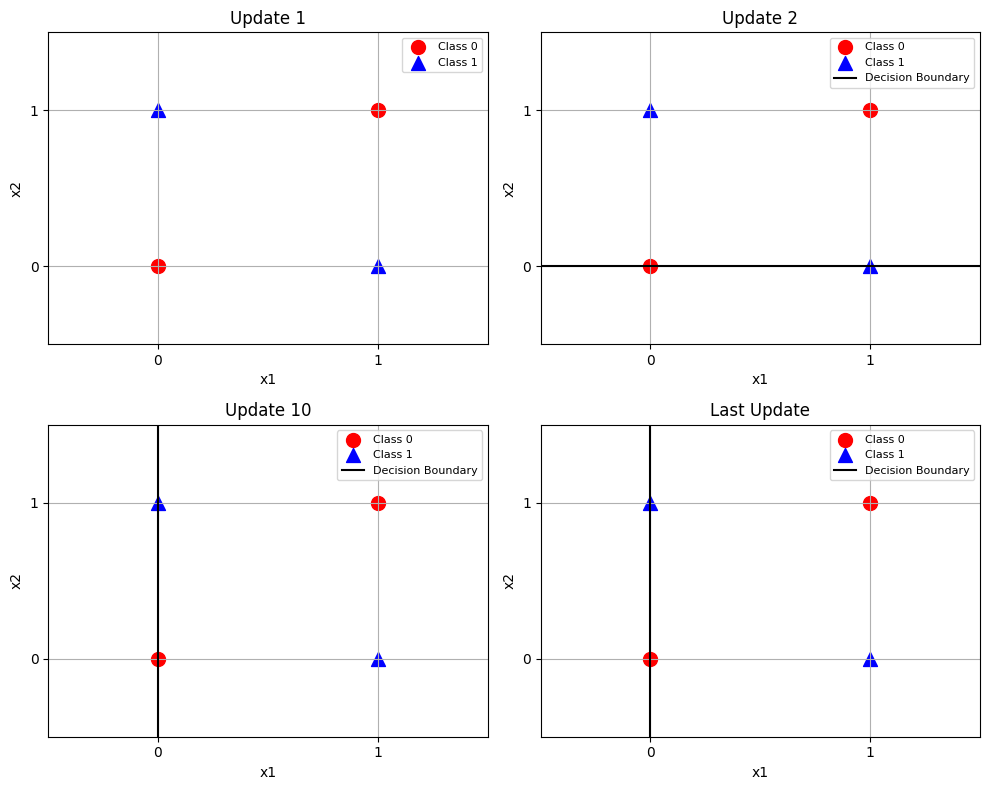

--------------------
Final Weights: [-0.1  0. ]
Final Bias: 0.0
Total Updates: 38
Training did not converge because XOR is not linearly separable.


In [30]:
data=np.array([[0,0],[0,1],[1,0],[1,1]])
target=np.array([0,1,1,0])

w=np.zeros(2)
b=0
lr=0.1
epochs=10

os.makedirs("Figures",exist_ok=True)

def step(z):
    if z>=0:
        return 1
    return 0

fig,axes=plt.subplots(2,2,figsize=(10,8))
axes=axes.flatten()

def plot_boundary(ax,w,b,data,target,title):
    for i in range(len(data)):
        if target[i]==0:
            ax.scatter(data[i][0],data[i][1],c='red',marker='o',s=100,label='Class 0' if i==0 else "")
        else:
            ax.scatter(data[i][0],data[i][1],c='blue',marker='^',s=100,label='Class 1' if i==1 else "")

    if abs(w[1])>1e-8:
        x=np.linspace(-0.5,1.5,100)
        y=-(w[0]*x+b)/w[1]
        ax.plot(x,y,'k',label='Decision Boundary')
    elif abs(w[0])>1e-8:
        ax.axvline(-b/w[0],color='black',label='Decision Boundary')

    ax.set_xlim(-0.5,1.5)
    ax.set_ylim(-0.5,1.5)
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    ax.grid(True)
    ax.legend(fontsize=8)

update_count=0
last_w=None
last_b=None

for epoch in range(epochs):
    print("Epoch",epoch+1)

    for x,actual in zip(data,target):

        z=np.dot(w,x)+b
        pred=step(z)
        error=actual-pred

        w=w+lr*x*error
        b=b+lr*error

        if error!=0:

            update_count+=1

            print("Update",update_count)
            print("Input",x)
            print("Weights",w)
            print("Bias",b)

            last_w=w.copy()
            last_b=b

            if update_count==1:
                plot_boundary(axes[0],w,b,data,target,"Update 1")

            elif update_count==2:
                plot_boundary(axes[1],w,b,data,target,"Update 2")

            elif update_count==10:
                plot_boundary(axes[2],w,b,data,target,"Update 10")

if last_w is not None:
    plot_boundary(axes[3],last_w,last_b,data,target,"Last Update")

plt.tight_layout()
plt.savefig("Figures/XOR_Decision_Boundary.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")
plt.show()

print("-"*20)
print("Final Weights:",w)
print("Final Bias:",b)
print("Total Updates:",update_count)
print("Training did not converge because XOR is not linearly separable.")